# Basic Usage

This notebook demonstrates basic inference using our pre-trained model.

1. Load packages. Please refer to the `environment.yml` file for the full list of dependencies. 

In [ ]:
import os
import sys
import math
import random
import torch

sys.path.append("..")
from io import BytesIO
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import requests
import zarr
import matplotlib.pyplot as plt
from PIL import Image
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from torch.utils.data import DataLoader
from huggingface_hub import hf_hub_download

from utils.data_processing import MultimodalDataset
from utils.astro_image_functions import make_rgb
from models.mae import MaskedAutoencoderViT

from utils.data_processing import (
    generate_rest_indices,
    get_extreme_mask,
    get_kernel,
    safe_collate,
    smooth_data,
    MultimodalDataset,
    CreateMultimodalDataLoadersIter,
)

2. Load the pre-trained model checkpoint.

In [16]:
# a) Load from NERSC
# path = "/pscratch/sd/p/pzehao/DESIMAE/ProductionCheckpointsSimple/epoch=119-val_loss=-1.5850.ckpt"

# b) Load from Hugging Face Hub @ huggingface.co/pengzehao/MultimodalHF 
path = hf_hub_download(
    repo_id="pengzehao/MultimodalHF",
    filename="pretrained.ckpt",
)

prob = 0.7/15 # <- sample probability only relevant at training time

model = MaskedAutoencoderViT(spec_dim=7781,
        max_epochs=600,
        warmup_epoch=5,
        mask_ratio=0.75,
        embed_dim        = 256,
        merged_depth     = 4,
        merged_num_heads = 8,
        s_depth          = 4,
        e_depth          = 4,
        s_num_heads      = 8,
        e_num_heads      = 8,
        decoder_embed_dim= 512,
        decoder_depth    = 8,
        decoder_num_heads= 16,
        decoder_MLP_coefficient = 1,
        patch_scheme={
            "patch_sizes": [1, 1, 2, 4, 8, 16, 32, 64, 128, 64, 32, 16, 8, 4, 2, 1],
            "mask_ratios": [1, 0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.2, 0.1, 0.0],
            "probs": [0.3, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob]
        })
# load model from checkpoint (non-strict for backward compatibility)
checkpoint = torch.load(path, map_location="cpu")
model.load_state_dict(checkpoint["state_dict"], strict=False)
model.eval()

/tmp/ipykernel_1209389/2555331531.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location="cpu")


MaskedAutoencoderViT(
  (patch_embed1d): PatchEmbed1D(
    (proj): Conv1d(1, 256, kernel_size=(31,), stride=(31,))
    (norm): Identity()
  )
  (patch_embedimg): PatchEmbed(
    (proj): Conv2d(1, 256, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (s_attn): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (act): GELU(approximate='none')
        (d

3. Build an example dataset drawn from DESI data. We also demonstrate a call to the `CreateMultimodalDataLoadersIter` function, which creates and splits dataloaders.

In [3]:
train_loader, val_loader, test_loader = CreateMultimodalDataLoadersIter(end=10000, train_size=3000, batch_size=32)

4. Example forward pass on one batch of data. Here we showcase the model's ability to infer spectra from images by setting `model.mask_ratio_img = 0` for images and `model.mask_ratio = 1` for spectra. Feel free to adjust these values to check out different masking regimes! For example, setting both to 0.5 will demonstrate infilling of the two modalities.

In [4]:
batch = next(iter(val_loader))
x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch
model.mask_ratio_img = 0
model.mask_ratio = 1
spec_loss, img_loss, total_loss, spec_pred, error_pred, pred_img, error_img, token_mask = model.forward(spec, weig, error, img, img_w, img_e, z, xy_pix)

- `spec_pred`: Predicted spectra, $(B, 8401)$ where $8401 = $ $10 \times 31 \times 2$ left/right padded pixels $ + 7781$ DESI pixels.
- `error_pred`: $ln(\text{Predicted errors})$, $(B, 8401)$.
- `pred_img`: Predicted images, $(B, 98304)$. You can reshape one sample to $(6, 128, 128)$ with the following code block:
    - ```python
        p = pred_img[i].view(model.num_img_channels, N, model.img_patch, model.img_patch)
        p = p.view(model.num_img_channels, 128//model.img_patch, 128//model.img_patch, model.img_patch, model.img_patch)                  # (C, 8, 8, 16, 16)
        pred_img_formatted = p.permute(0,1,3,2,4).reshape(model.num_img_channels, 128, 128).detach().cpu().numpy()
      ```

- `error_img`: $ln(\text{Predicted image errors})$, $(B, 98304)$
- `token_mask`: Boolean mask indicating which tokens are masked, $(636)$. $636$ is the total length of the concatenated image ($8 \times 8 \times 6 = 384$) and spectra ($7781 / 31 = 251$) token sequences, and a class token ($1$).

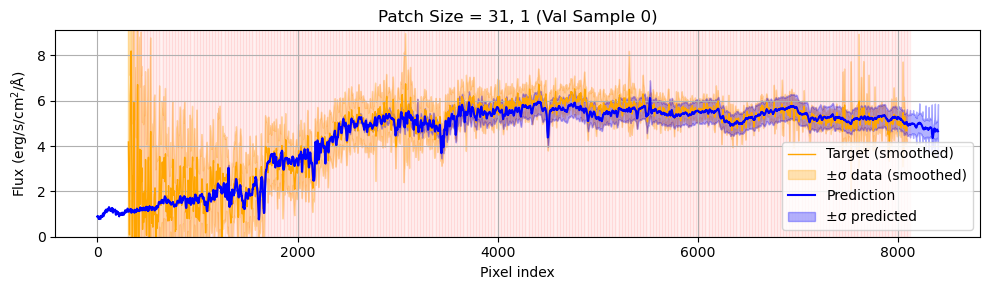

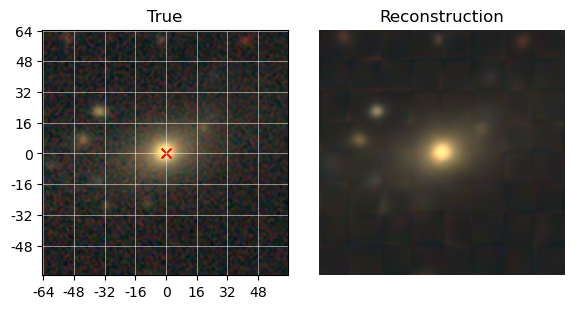

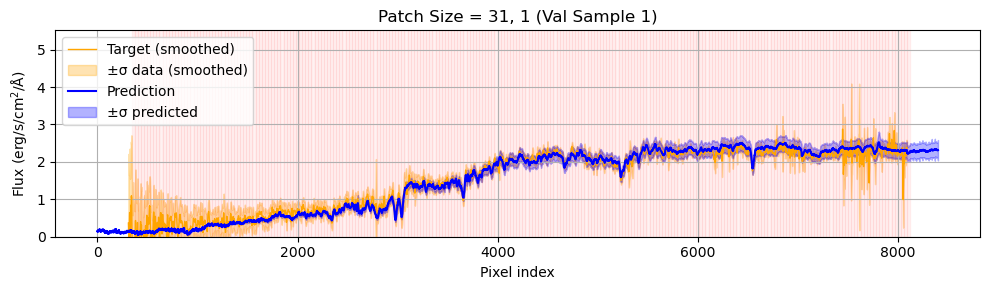

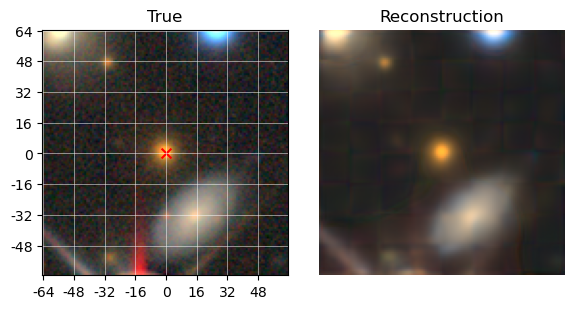

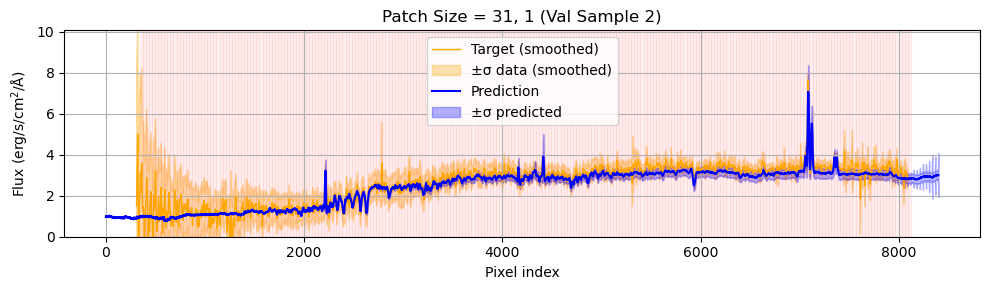

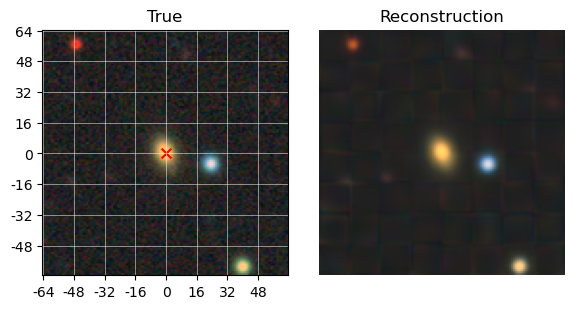

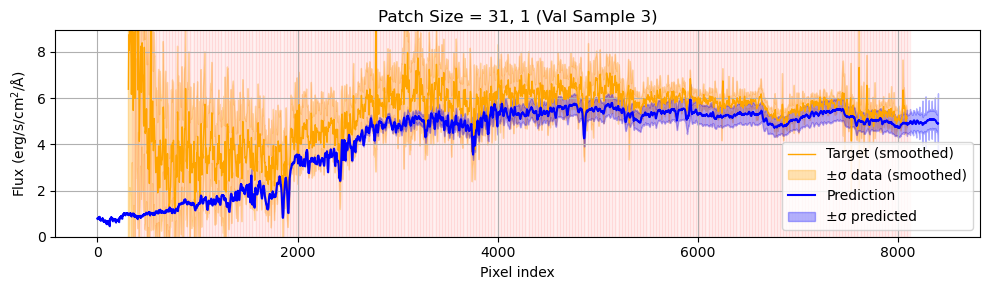

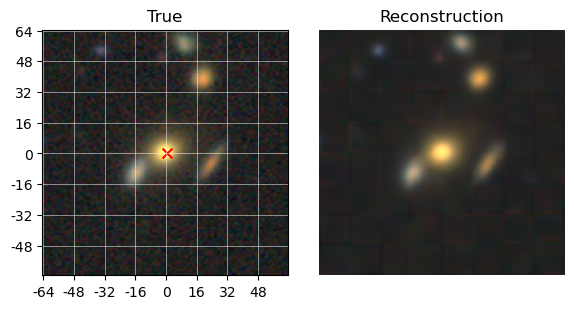

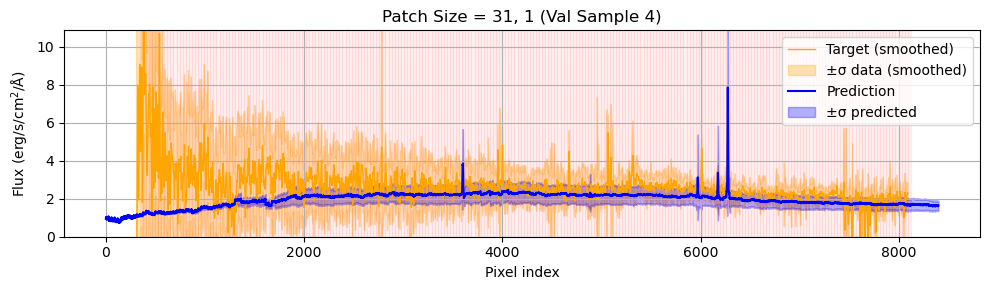

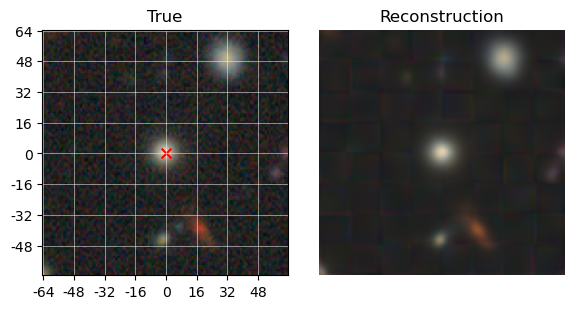

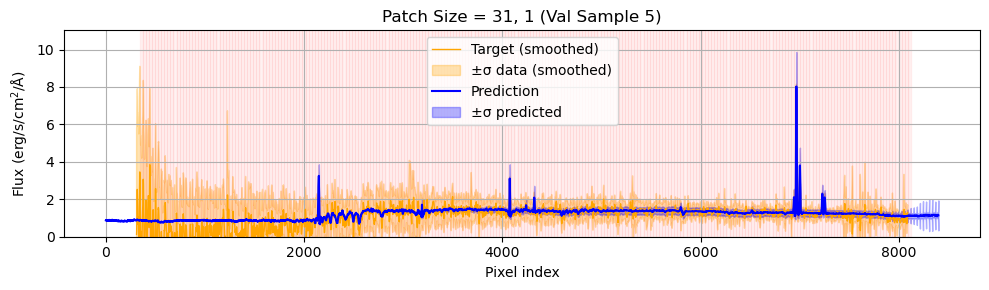

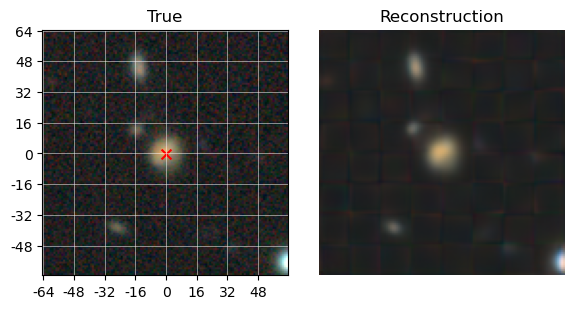

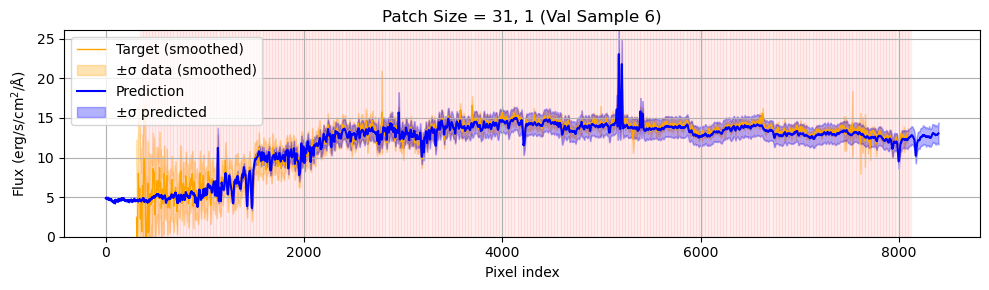

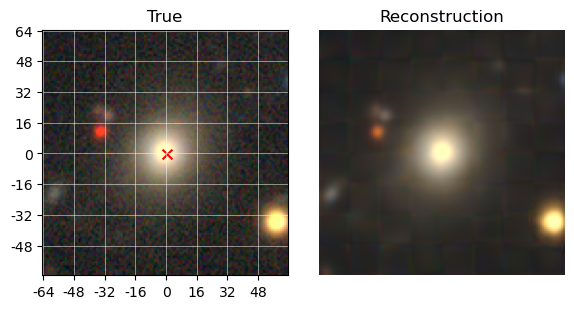

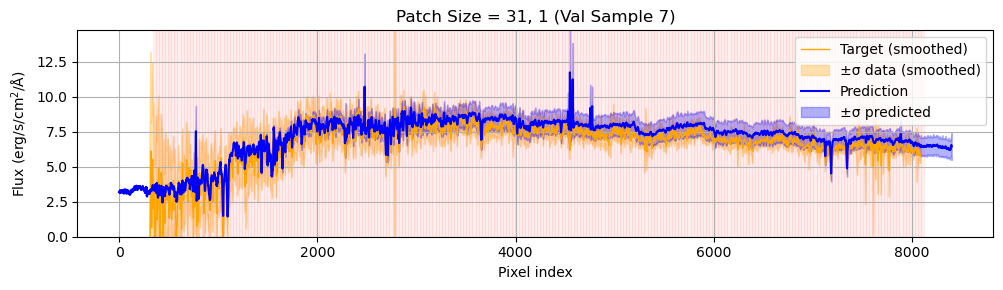

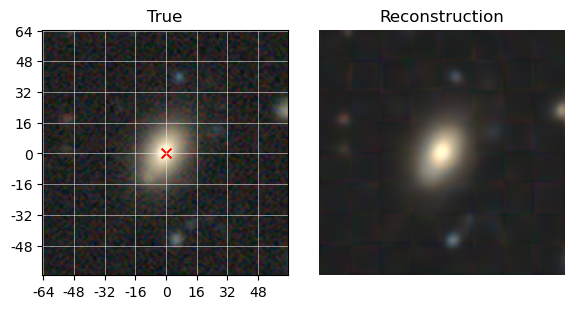

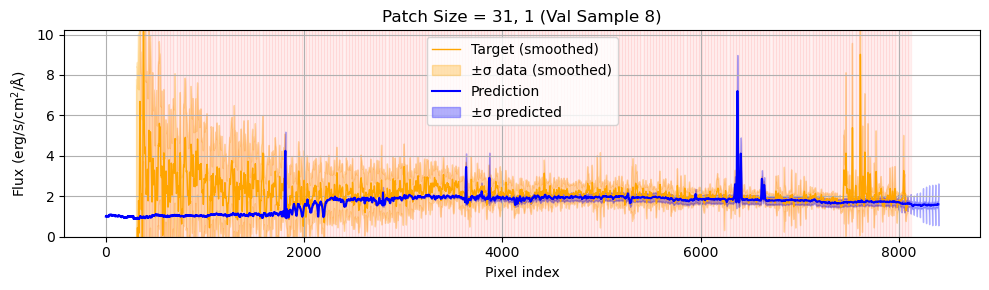

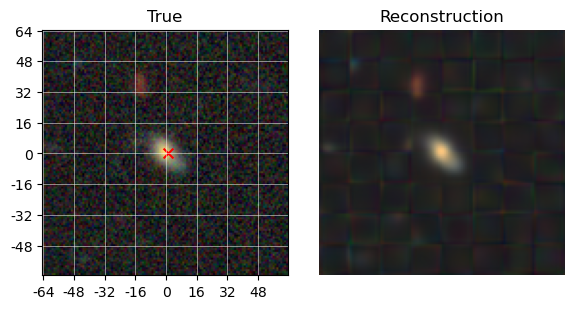

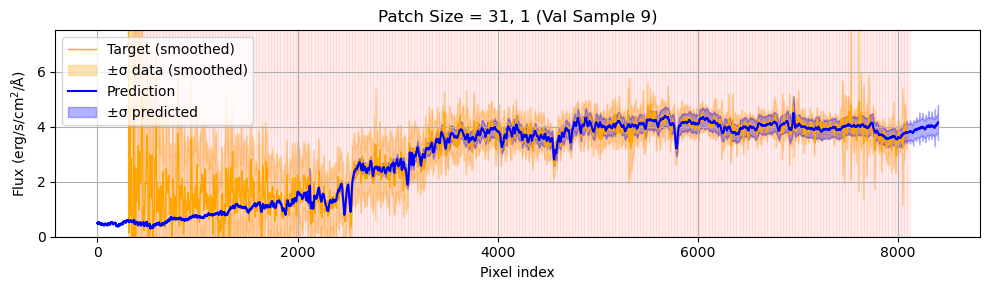

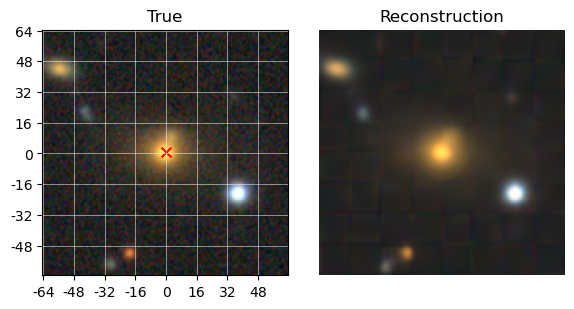

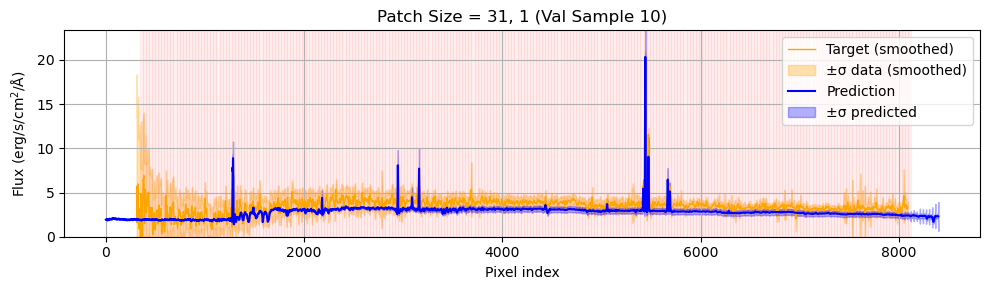

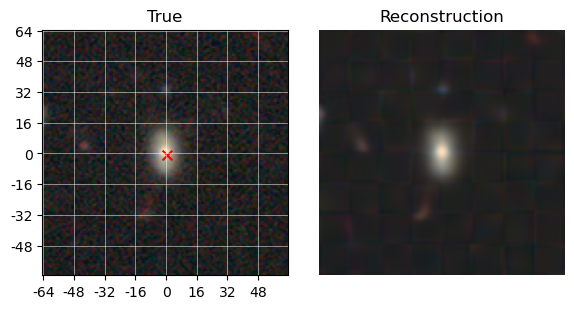

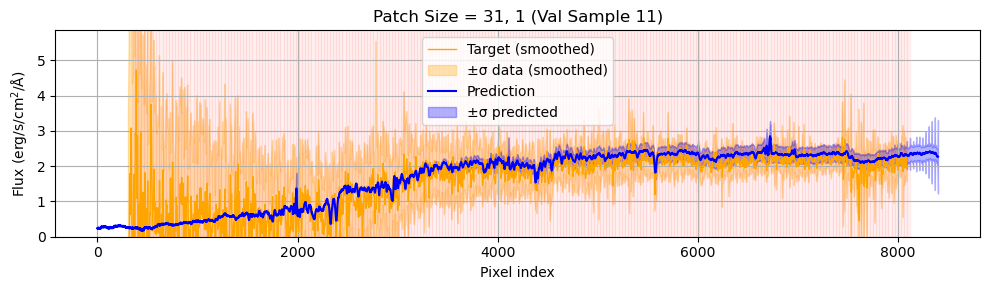

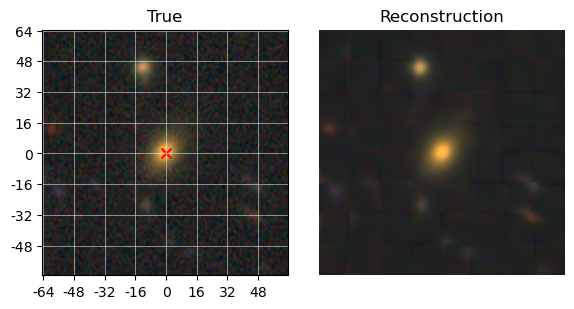

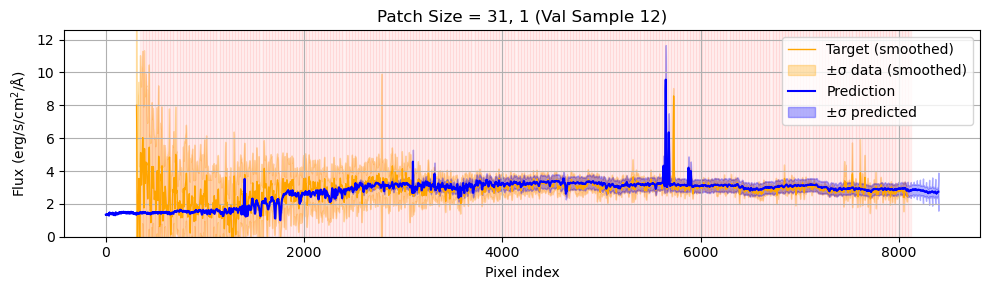

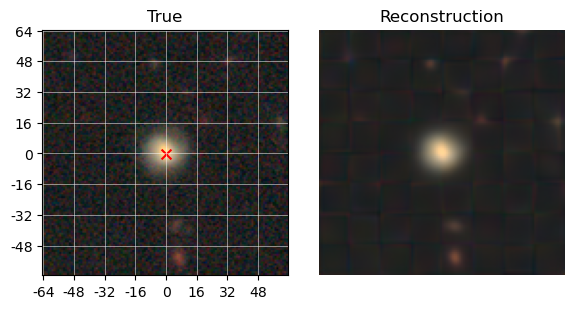

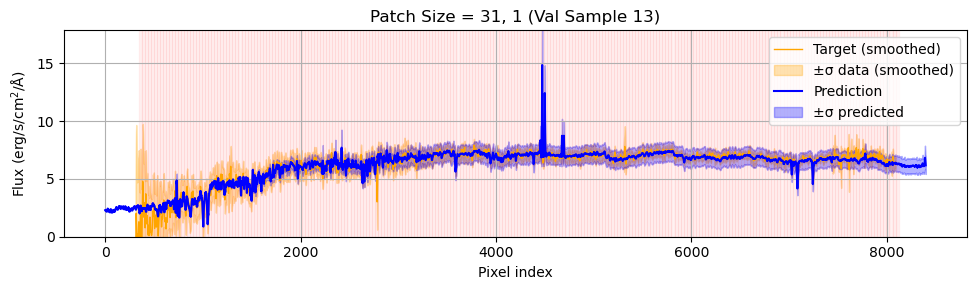

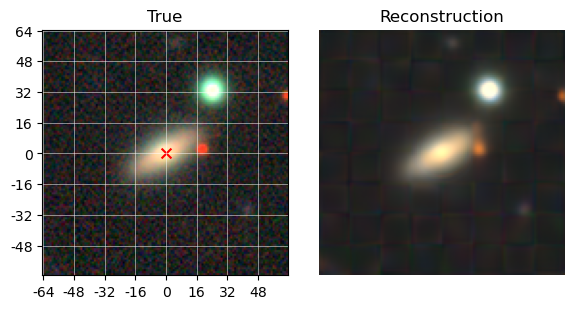

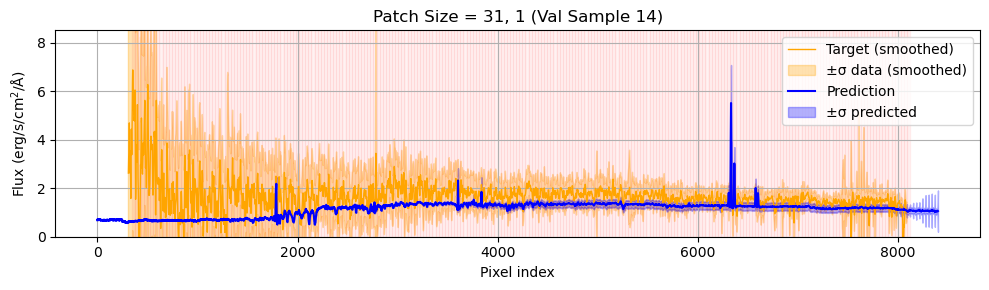

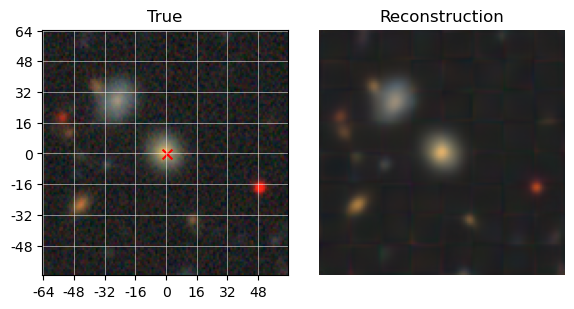

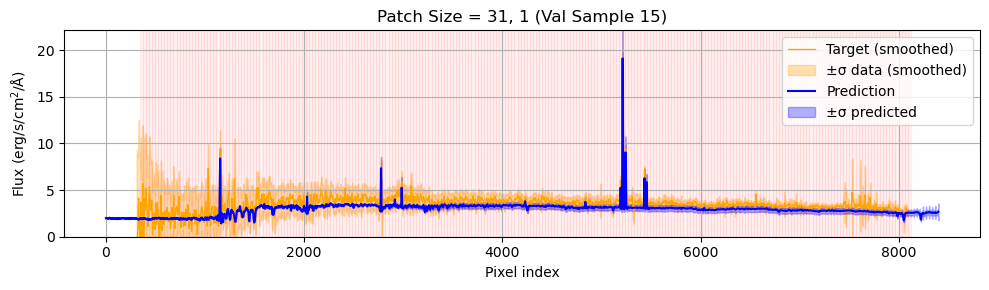

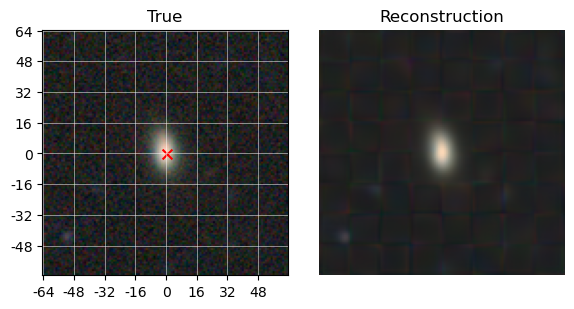

In [6]:
# Good visualization helper, especially when the masking ratio is not 0 or 1
def visualize(model, spec: torch.Tensor, error: torch.Tensor, spec_pred: torch.Tensor, 
                error_pred: torch.Tensor, img: torch.Tensor, pred_img: torch.Tensor, error_img: torch.Tensor, mask_spec: torch.Tensor, mask_img: torch.Tensor, xy_pix: torch.Tensor,
                i: int = 0, ylim: int = 25, nsmooth: int = 3):
    kernel = get_kernel(nsmooth)

    # Extract relevant sample
    target = spec[i].detach().cpu().numpy()
    target_error = error[i].detach().cpu().numpy()
    pred_mean = spec_pred[i].detach().cpu().numpy()
    pred_sigma = np.exp(error_pred[i].detach().cpu().numpy())
    patch_mask_spec = mask_spec[i].detach().cpu()
    patch_mask_img = mask_img[i].detach().cpu()

    # Smooth signal and error
    target_smooth = smooth_data(target, kernel)
    target_error_smooth = smooth_data(target_error, kernel)

    # Compute intervals
    pred_upper = pred_mean + pred_sigma
    pred_lower = pred_mean - pred_sigma
    data_upper = target_smooth + target_error_smooth
    data_lower = target_smooth - target_error_smooth

    # Plot masked reconstruction
    fig, ax = plt.subplots(figsize=(10, 3))
    offset = model.left_patches * model.patch_size
    x_range = np.arange(offset, offset + len(target_smooth))
    ax.plot(x_range, target_smooth, label="Target (smoothed)", color="orange", linewidth=1)
    ax.fill_between(x_range, data_lower, data_upper, color="orange", alpha=0.3, label="±σ data (smoothed)")
    ax.plot(pred_mean, label="Prediction", color="blue")
    ax.fill_between(range(len(pred_mean)), pred_lower, pred_upper, color="blue", alpha=0.3, label="±σ predicted")
    patch_len = model.patch_size
    for j, masked in enumerate(patch_mask_spec):
        if masked:
            start = offset + j * patch_len
            end = offset + (j + 1) * patch_len
            ax.axvspan(start, end, color='red', alpha=0.05)
    ax.set_title(f"Patch Size = {model.patch_size*model.chunk_size}, {model.mask_ratio} (Val Sample {i})")
    ax.set_xlabel("Pixel index")
    ax.set_ylabel("Flux ($\mathrm{erg/s/cm^2/\AA}$)")
    ax.set_ylim(0, ylim)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    N = model.patch_embedimg.num_patches
    p = pred_img[i].view(model.num_img_channels, N, model.img_patch, model.img_patch)
    p = p.view(model.num_img_channels, 128//model.img_patch, 128//model.img_patch, model.img_patch, model.img_patch)                  # (C, 8, 8, 16, 16)
    pred_img_formatted = p.permute(0,1,3,2,4).reshape(model.num_img_channels, 128, 128).detach().cpu().numpy()
    
    img_formatted = img[i].detach().cpu().numpy() 
    pred_rgb = make_rgb(pred_img_formatted[[0, 1, 3]], "ls_grz") 
    img_rgb = make_rgb(img_formatted[[0, 1, 3]], "ls_grz") 
    
    # mask: (384,) -> (6,64) -> (6,8,8)
    # m = patch_mask_img.float().view(6, 64).view(6, 8, 8)

    # # opacity per spatial patch = fraction of channels masked
    # alpha_patch = m.mean(dim=0).cpu().numpy()                 # (8,8)
    # alpha128 = np.kron(alpha_patch, np.ones((16, 16)))        # (128,128)
    xy_pix_val = xy_pix[i].detach().cpu().numpy()

    fig2, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(img_rgb)
    axs[0].set_title("True")

    ticks = np.arange(0, 129, 16)
    axs[0].set_xticks(ticks)
    axs[0].set_yticks(ticks)

    axs[0].set_xticklabels(ticks - 64)
    axs[0].set_yticklabels(64 - ticks)

    axs[0].grid(True, color='white', alpha=0.7, linewidth=0.5)

    axs[0].scatter(
        xy_pix_val[0] + 64,
        64 - xy_pix_val[1],
        c='red', s=50, marker='x'
    )

    axs[1].imshow(pred_rgb)
    # axs[1].imshow(alpha128, cmap="Reds", alpha=alpha128)
    axs[1].set_title("Reconstruction")
    axs[1].axis("off")

    plt.tight_layout()
    
    plt.show()
    plt.close(fig)
    plt.close(fig2)

token_mask = token_mask.unsqueeze(0).expand(spec.size(0), -1)
mask_spec = token_mask[:, :-model.num_patchesimg].long()
mask_img = token_mask[:, -model.num_patchesimg:].long()
for i in range(16):
    ylim_val = float(spec_pred[i].detach().max().cpu()) + 3.0
    visualize(model, spec, error, spec_pred, error_pred, img, pred_img, error_img, mask_spec, mask_img, xy_pix, i, ylim=ylim_val)

5. Perturbing the fibre location: we now isolate one sample and demonstrate spatially-resolved spectra generation. This can be done by setting `xy_pix`, which is the pixel location of the fibre, to a different value. We can then visualize the predicted spectra at different locations.

In [7]:
# For this demo, let's select a more interesting object! 
TARGETID = 39628444518058848 # <- This is the object from figure 2 in our paper.
# MANGAID = 9042-9101
DESI_PARQUET = Path("/pscratch/sd/p/pzehao/iron/desi_zcat_maglim_19_5.parquet")
DESI_ZARR = Path("/pscratch/sd/p/pzehao/iron/desi_maglim_19_5.zarr")

desi_tab = pd.read_parquet(DESI_PARQUET, columns=["TARGETID"])
desi_index = int(desi_tab.index[desi_tab["TARGETID"].astype(np.int64).eq(TARGETID)][0])

ds = MultimodalDataset(str(DESI_ZARR), start=desi_index, end=desi_index + 1, augment=False, max_shift=0)
batch = next(iter(DataLoader(ds, batch_size=1, shuffle=False)))
x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch
print(xy_pix) # <- Actual DESI fibre location from metadata - very close to the centre of the image!

tensor([[ 0.5535, -0.1310]])


Using the DESI fibre location.

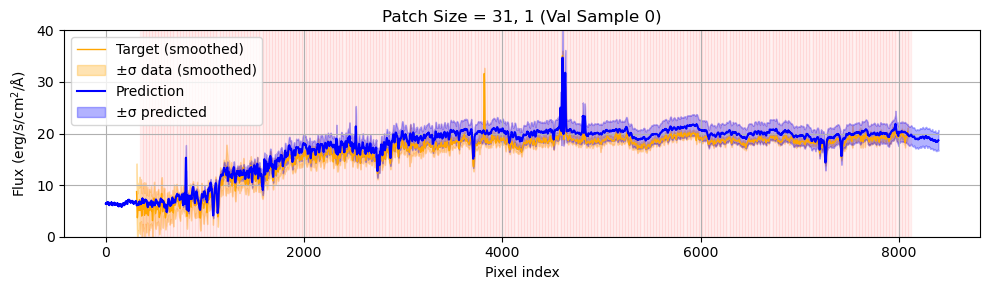

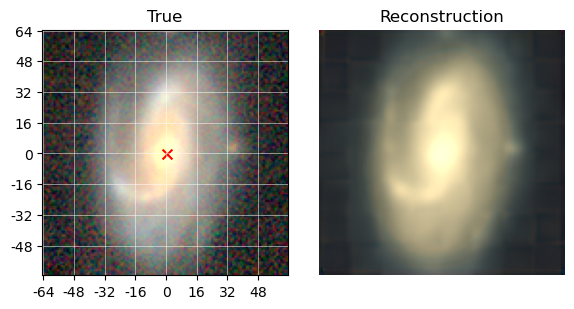

In [8]:
spec_loss, img_loss, total_loss, spec_pred, error_pred, pred_img, error_img, token_mask = model.forward(spec, weig, error, img, img_w, img_e, z, xy_pix)
visualize(model, spec, error, spec_pred, error_pred, img, pred_img, error_img, mask_spec, mask_img, xy_pix, i=0, ylim=40)

Setting an arbitrary fibre location. Note that the ground truth spectrum (orange) is only available at the DESI location.

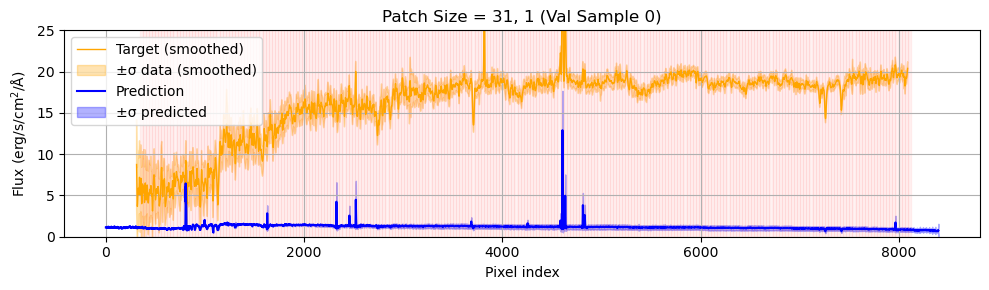

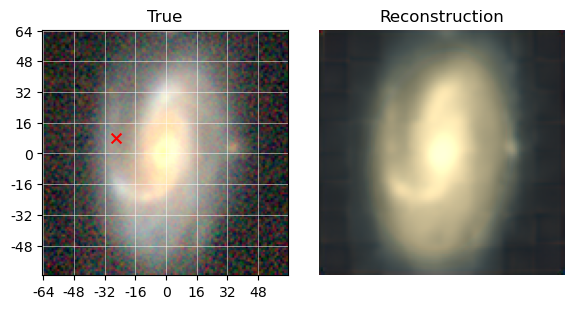

In [9]:
xy_pix = torch.tensor([[-26.0, 8.0]]) # <- setting the fibre location
spec_loss, img_loss, total_loss, spec_pred, error_pred, pred_img, error_img, token_mask = model.forward(spec, weig, error, img, img_w, img_e, z, xy_pix)
visualize(model, spec, error, spec_pred, error_pred, img, pred_img, error_img, mask_spec, mask_img, xy_pix, i=0)

A quick scan over $(0, y)$ for $y \in \{64, 56, 48, 40, 32, 24, 16, 8, 0\}$.

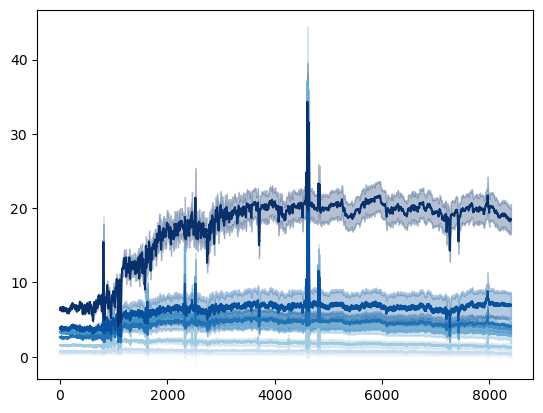

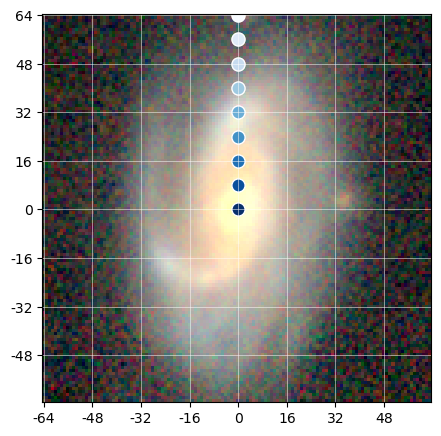

In [10]:
init = 64
ys = [init - i * 8.0 for i in range(9)]
norm = plt.Normalize(vmin=min(ys), vmax=max(ys))
cmap = plt.cm.Blues_r
for i, y_val in enumerate(ys):
    xy_pix = torch.tensor([[0.0, y_val]])
    _, _, _, spec_pred, error_pred, _, _, _ = model.forward(spec, weig, error, img, img_w, img_e, z, xy_pix)
    color = cmap(norm(y_val))
    plt.plot(spec_pred[0].detach().cpu().numpy(), color=color, label=f"xy_pix = {xy_pix.numpy()[0]}")
    plt.fill_between(
        range(len(spec_pred[0])),
        spec_pred[0].detach().cpu().numpy() - np.exp(error_pred[0].detach().cpu().numpy()),
        spec_pred[0].detach().cpu().numpy() + np.exp(error_pred[0].detach().cpu().numpy()),
        color=color,
        alpha=0.3,
    )

img_formatted = img[0].detach().cpu().numpy()
img_rgb = make_rgb(img_formatted[[0, 1, 3]], "ls_grz")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(img_rgb)
ticks = np.arange(0, 129, 16)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(ticks - 64)
ax.set_yticklabels(64 - ticks)
ax.grid(True, color='white', alpha=0.7, linewidth=0.5)

for y_val in ys:
    color = cmap(norm(y_val))
    ax.scatter(64, 64 - y_val, s=90, marker='o', facecolor=color, edgecolor='white', linewidth=1.0)

plt.tight_layout()